#CELL 0: Environment Setup & Repository Cloning

In [1]:
# 1. Clone your repository (Replace with your exact repo URL if different)
!git clone https://github.com/shawkath73/Subtype-HM-optimized.git

# 2. Change directory into the project
%cd Subtype-HM-optimized

# 3. Install required dependencies
!pip install torch torchvision torchaudio
!pip install scikit-learn pandas numpy matplotlib seaborn lifelines faiss-cpu

Cloning into 'Subtype-HM-optimized'...
remote: Enumerating objects: 54, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 54 (delta 6), reused 51 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (54/54), 16.59 MiB | 17.49 MiB/s, done.
Resolving deltas: 100% (6/6), done.
/content/Subtype-HM-optimized
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 98.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 7.7 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=95604e11e9738c4aa4677943335984e6552964f1c256d5dcffcc43f99d110203
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


#Cell 1: Setup, Path Fix, and Data Loading

In [2]:
import sys
import os

# --- FIX: BYPASS THE NESTED FOLDER ---
repo_path = '/content/Subtype-HM-optimized/Subtype-HM'
if os.path.exists(repo_path):
    sys.path.append(repo_path)
    os.chdir(repo_path)
    print(f"Successfully entered project directory: {os.getcwd()}")
else:
    print(f"Warning: {repo_path} not found. Check your clone path.")

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix
from sklearn.preprocessing import label_binarize
from torch.utils.data import DataLoader

# Import custom modules
from Subtype_HM import Network
from dataloader_brca import load_brca_data

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs('./results', exist_ok=True)

# Load Shared Data
dataset, dims, data_size = load_brca_data()
data_loader = DataLoader(dataset, batch_size=256, shuffle=False)

CLASS_NUM = 5
subtype_names = ['Luminal A', 'Luminal B', 'HER2-enriched', 'Basal-like', 'Normal-like']

# Global arrays to store results across cells
true_labels = []
single_omic_preds = []
multi_omic_probs = []
multi_omic_preds = []

Successfully entered project directory: /content/Subtype-HM-optimized/Subtype-HM
[cache] Loading brca_mrna.csv
[cache] Loading brca_methy.csv
[cache] Loading brca_mirna.csv
[cache] Loading brca_clinical_xena.tsv
[survival] Loaded 1228 real TCGA BRCA survival records.
[Variance] Selecting top 1500 features by variance for mRNA...
[Variance] mRNA: selected 1000 / 1000 features.
[Variance] Selecting top 1500 features by variance for Methylation...
[Variance] Methylation: selected 1000 / 1000 features.
[Variance] Selecting top 1500 features by variance for miRNA...
[Variance] miRNA: selected 503 / 503 features.
[BRCA] mRNA features   : 1000
[BRCA] Methylation feat: 1000
[BRCA] miRNA features  : 503
[BRCA] Samples         : 875
[BRCA] Survival — events (dead): 175/875 (20.0%)


# CELL 3: Define Single-Omic Hypergraph Network

In [6]:
import torch
import torch.nn as nn
from HIL import HypergraphConstruction, HypergraphPropagationModule
from Subtype_HM import Encoder, Decoder

class SingleOmicNetwork(nn.Module):
    """
    Same hypergraph architecture as Network, but for exactly 1 omic view.
    Bypasses MultiModalClassifier (hardcoded for 3 views).
    Uses a simple linear domain projection instead.
    """
    def __init__(self, input_dim, feature_dim, class_num, layer_num, device):
        super(SingleOmicNetwork, self).__init__()
        self.device = device
        self.feature_dim = feature_dim
        self.class_num = class_num

        self.encoder = Encoder(input_dim, feature_dim).to(device)
        self.decoder = Decoder(input_dim, feature_dim).to(device)

        self.hypergraph_constructor = HypergraphConstruction(k=20)
        self.hypergraph = HypergraphPropagationModule(
            input_dim=feature_dim,
            hidden_dim=feature_dim,
            output_dim=feature_dim,
            dk=64,
            layer_num=layer_num
        )

        # Simple linear projection replacing MultiModalClassifier
        # (feature_dim from hypergraph) + (feature_dim from linear proj) = feature_dim * 2
        self.domain_proj = nn.Linear(feature_dim, feature_dim)

        self.label_contrastive_module = nn.Sequential(
            nn.Linear(feature_dim * 2, class_num),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        """x: tensor of shape (batch, input_dim)"""
        z = self.encoder(x)                        # (N, feature_dim)
        zs = [z]                                   # wrap as list for hypergraph

        X = z                                      # single view, no cat needed
        H_s, H_o, H_c = self.hypergraph_constructor.construct_full_hypergraph(
            zs, cluster_num=self.class_num
        )
        X_updated = self.hypergraph(X, zs, H_s, H_o, H_c)  # tuple of 1 tensor

        z_hyp = X_updated[0]                       # (N, feature_dim)
        z_proj = self.domain_proj(z)               # (N, feature_dim)

        z_cat = torch.cat([z_hyp, z_proj], dim=1) # (N, feature_dim*2)
        q = self.label_contrastive_module(z_cat)   # (N, class_num)
        xr = self.decoder(z)
        return q, xr, z

    def forward_pre(self, x):
        z = self.encoder(x)
        xr = self.decoder(z)
        return xr, z

    def forward_cluster(self, x):
        q, _, z = self.forward(x)
        pred = torch.argmax(q, dim=1)
        return q, pred


# ── Monkey-patch HypergraphConstruction to clamp k safely ──
_orig_modality = HypergraphConstruction.construct_modality_hypergraph

def _safe_modality_hypergraph(self, X, k):
    safe_k = min(k, X.shape[0] - 1)
    return _orig_modality(self, X, safe_k)

HypergraphConstruction.construct_modality_hypergraph = _safe_modality_hypergraph
print("✅ Patched HypergraphConstruction.construct_modality_hypergraph with safe k clamping")

# ── Quick sanity check ──────────────────────────────────────
_test_input = torch.randn(8, dims[0]).to(device)
_so_test = SingleOmicNetwork(
    input_dim=dims[0], feature_dim=32, class_num=CLASS_NUM,
    layer_num=3, device=device
).to(device)
_q, _xr, _z = _so_test(_test_input)
print(f"✅ SingleOmicNetwork OK — q:{_q.shape}, xr:{_xr.shape}, z:{_z.shape}")
del _so_test, _test_input, _q, _xr, _z

✅ Patched HypergraphConstruction.construct_modality_hypergraph with safe k clamping
✅ SingleOmicNetwork OK — q:torch.Size([8, 5]), xr:torch.Size([8, 1000]), z:torch.Size([8, 32])


# CELL 4: Train Single-Omic Hypergraph Model (mRNA only)

In [7]:
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader
from MCEA import Align_Loss

FEATURE_DIM   = 32
LAYER_NUM     = 3
LR            = 0.0005
MSE_EPOCHS    = 10
CON_EPOCHS    = 400
BATCH_SIZE    = 1024
SUP_WEIGHT    = 200.0

torch.manual_seed(10)

so_model = SingleOmicNetwork(
    input_dim=dims[0], feature_dim=FEATURE_DIM,
    class_num=CLASS_NUM, layer_num=LAYER_NUM, device=device
).to(device)

so_optimizer = torch.optim.Adam(so_model.parameters(), lr=LR)
so_scheduler = lr_scheduler.CosineAnnealingLR(
    so_optimizer, T_max=MSE_EPOCHS + CON_EPOCHS, eta_min=1e-6
)
mse_loss_fn = nn.MSELoss()
nll_loss_fn = nn.NLLLoss()

# Re-use existing data_loader (already created in Cell 2)
so_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False, num_workers=0)

# ── Phase 1: Autoencoder pretraining ──────────────────────
print("=" * 50)
print("Phase 1: Autoencoder Pretraining")
print("=" * 50)
for epoch in range(1, MSE_EPOCHS + 1):
    so_model.train()
    tot = 0.
    for xs, _, _, _ in so_loader:
        x_mrna = xs[0].to(device)          # only mRNA view
        so_optimizer.zero_grad()
        xr, z = so_model.forward_pre(x_mrna)
        loss = mse_loss_fn(x_mrna, xr)
        loss.backward()
        nn.utils.clip_grad_norm_(so_model.parameters(), 1.0)
        so_optimizer.step()
        tot += loss.item()
    so_scheduler.step()
    if epoch % 2 == 0 or epoch == 1:
        print(f"  [Pre]  Epoch {epoch:>3}/{MSE_EPOCHS}  Loss: {tot/len(so_loader):.6f}")

# ── Phase 2: Contrastive + Supervised training ────────────
print("\n" + "=" * 50)
print("Phase 2: Contrastive + Supervised Training")
print("=" * 50)

for epoch in range(1, CON_EPOCHS + 1):
    so_model.train()
    tot = 0.
    for xs, _, _, labels in so_loader:
        x_mrna  = xs[0].to(device)
        labels  = labels.to(device)
        so_optimizer.zero_grad()

        q, xr, z = so_model(x_mrna)

        loss_recon = mse_loss_fn(x_mrna, xr)
        loss_sup   = nll_loss_fn(torch.log(q + 1e-8), labels)
        loss_ent   = (-(q * torch.log(q + 1e-8)).sum(dim=1)).mean()   # entropy reg

        loss = loss_recon + loss_ent + loss_sup * SUP_WEIGHT
        loss.backward()
        nn.utils.clip_grad_norm_(so_model.parameters(), 1.0)
        so_optimizer.step()
        tot += loss.item()

    so_scheduler.step()
    if epoch % 40 == 0 or epoch == 1:
        print(f"  [Con]  Epoch {epoch:>3}/{CON_EPOCHS}  Loss: {tot/len(so_loader):.6f}")

# Save checkpoint
torch.save(so_model.state_dict(), './models/BRCA_SingleOmic.pth')
print("\n✅ Single-omic model trained and saved to ./models/BRCA_SingleOmic.pth")

Phase 1: Autoencoder Pretraining
  [Pre]  Epoch   1/10  Loss: 0.441322
  [Pre]  Epoch   2/10  Loss: 0.351516
  [Pre]  Epoch   4/10  Loss: 0.230892
  [Pre]  Epoch   6/10  Loss: 0.163337
  [Pre]  Epoch   8/10  Loss: 0.129177
  [Pre]  Epoch  10/10  Loss: 0.110197

Phase 2: Contrastive + Supervised Training
  [Con]  Epoch   1/400  Loss: 327.497101
  [Con]  Epoch  40/400  Loss: 70.860977
  [Con]  Epoch  80/400  Loss: 42.163673
  [Con]  Epoch 120/400  Loss: 32.489590
  [Con]  Epoch 160/400  Loss: 30.994070
  [Con]  Epoch 200/400  Loss: 30.862663
  [Con]  Epoch 240/400  Loss: 27.196253
  [Con]  Epoch 280/400  Loss: 29.211578
  [Con]  Epoch 320/400  Loss: 28.007633
  [Con]  Epoch 360/400  Loss: 27.050390
  [Con]  Epoch 400/400  Loss: 27.600174

✅ Single-omic model trained and saved to ./models/BRCA_SingleOmic.pth


# CELL 5: Inference — collect predictions & probabilities

In [9]:
from sklearn.preprocessing import label_binarize
import numpy as np

eval_loader = DataLoader(dataset, batch_size=256, shuffle=False, drop_last=False, num_workers=0)

# ── Infer correct dim order directly from checkpoint ────────
checkpoint = torch.load('./models/BRCA.pth', map_location=device)

# Extract encoder input dims in the exact order they were saved
saved_dims = []
v = 0
while f'encoders.{v}.encoder.0.weight' in checkpoint:
    saved_dims.append(checkpoint[f'encoders.{v}.encoder.0.weight'].shape[1])
    v += 1

print(f"Dims found in checkpoint (saved order): {saved_dims}")
# Expected: [1000, 1000, 503]  →  mRNA, Meth, miRNA (the order run.py trained them)

# ── Load multi-omic model with checkpoint's own dim order ───
mo_model = Network(
    view=3,
    input_size=saved_dims,          # ← use checkpoint dims, not dims[]
    feature_dim=FEATURE_DIM,
    class_num=CLASS_NUM,
    layer_num=LAYER_NUM,
    device=device
).to(device)
mo_model.load_state_dict(checkpoint)
mo_model.eval()
print("✅ Multi-omic model loaded from ./models/BRCA.pth")

# ── Build a matching eval loader using checkpoint's view order ──
# saved_dims order is [mRNA(1000), Meth(1000), miRNA(503)]
# dataset returns xs as  [xs[0]=mRNA, xs[1]=Meth, xs[2]=miRNA]
# Check which slot each saved_dim maps to:
#   saved_dims[0]=1000 → mRNA  → dataset xs[0]
#   saved_dims[1]=1000 → Meth  → dataset xs[1]
#   saved_dims[2]=503  → miRNA → dataset xs[2]
# If your checkpoint order differs, adjust view_order below accordingly.

checkpoint_to_dataset = []
dataset_dims = [dataset[0][0][v].shape[0] for v in range(3)]
print(f"Dataset xs dims: {dataset_dims}")

# Build a mapping: for each checkpoint slot, find matching dataset slot
for sd in saved_dims:
    # find which dataset view has this dim (first unused match)
    for dv, dd in enumerate(dataset_dims):
        if dd == sd and dv not in checkpoint_to_dataset:
            checkpoint_to_dataset.append(dv)
            break

print(f"Checkpoint slot → dataset slot mapping: {checkpoint_to_dataset}")

# ── Collect predictions ───────────────────────────────────
all_labels   = []
so_probs_all = []
mo_probs_all = []

with torch.no_grad():
    for xs, _, _, labels in eval_loader:
        x_mrna = xs[0].to(device)

        # Reorder xs to match checkpoint's view order
        xs_reordered = [xs[checkpoint_to_dataset[v]].to(device) for v in range(3)]

        # Single-omic inference
        so_model.eval()
        q_so, _, _ = so_model(x_mrna)
        so_probs_all.append(q_so.cpu().numpy())

        # Multi-omic inference (average across 3 views)
        qs_mo, _ = mo_model.forward_cluster(xs_reordered)
        mo_avg = sum([q.cpu().numpy() for q in qs_mo]) / 3.0
        mo_probs_all.append(mo_avg)

        all_labels.append(labels.numpy())

all_labels   = np.concatenate(all_labels,   axis=0)
so_probs_all = np.concatenate(so_probs_all, axis=0)
mo_probs_all = np.concatenate(mo_probs_all, axis=0)

so_preds = np.argmax(so_probs_all, axis=1)
mo_preds = np.argmax(mo_probs_all, axis=1)

print(f"\nSamples evaluated : {len(all_labels)}")
print(f"Single-omic ACC   : {(so_preds == all_labels).mean()*100:.2f}%")
print(f"Multi-omic  ACC   : {(mo_preds == all_labels).mean()*100:.2f}%")

Dims found in checkpoint (saved order): [1000, 1000, 503]
✅ Multi-omic model loaded from ./models/BRCA.pth
Dataset xs dims: [1000, 1000, 503]
Checkpoint slot → dataset slot mapping: [0, 1, 2]

Samples evaluated : 875
Single-omic ACC   : 90.17%
Multi-omic  ACC   : 91.66%


# CELL 6: Side-by-side Metrics (ACC / NMI / ARI)

In [10]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from scipy.optimize import linear_sum_assignment

def cluster_accuracy(y_true, y_pred, n_classes):
    """Hungarian-matched accuracy (same as evaluate_brca.py)."""
    cost = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cost[t, p] += 1
    row, col = linear_sum_assignment(-cost)
    return cost[row, col].sum() / len(y_true)

so_acc = cluster_accuracy(all_labels, so_preds, CLASS_NUM)
mo_acc = cluster_accuracy(all_labels, mo_preds, CLASS_NUM)

so_nmi = normalized_mutual_info_score(all_labels, so_preds)
mo_nmi = normalized_mutual_info_score(all_labels, mo_preds)

so_ari = adjusted_rand_score(all_labels, so_preds)
mo_ari = adjusted_rand_score(all_labels, mo_preds)

print("\n" + "="*55)
print(f"{'Metric':<10} {'Single-Omic (mRNA)':>20} {'Multi-Omic':>15}")
print("="*55)
print(f"{'ACC':<10} {so_acc*100:>19.2f}%  {mo_acc*100:>14.2f}%")
print(f"{'NMI':<10} {so_nmi:>20.4f}  {mo_nmi:>14.4f}")
print(f"{'ARI':<10} {so_ari:>20.4f}  {mo_ari:>14.4f}")
print("="*55)

# Save to results
with open('./results/SingleVsMulti_comparison.txt', 'w') as f:
    f.write(f"Metric        Single-Omic (mRNA)    Multi-Omic\n")
    f.write(f"ACC           {so_acc*100:.2f}%                {mo_acc*100:.2f}%\n")
    f.write(f"NMI           {so_nmi:.4f}                {mo_nmi:.4f}\n")
    f.write(f"ARI           {so_ari:.4f}                {mo_ari:.4f}\n")
print("✅ Saved to ./results/SingleVsMulti_comparison.txt")


Metric       Single-Omic (mRNA)      Multi-Omic
ACC                      90.17%           91.66%
NMI                      0.7570          0.7831
ARI                      0.8225          0.8570
✅ Saved to ./results/SingleVsMulti_comparison.txt


# CELL 7: ROC Curves — Single-Omic vs Multi-Omic

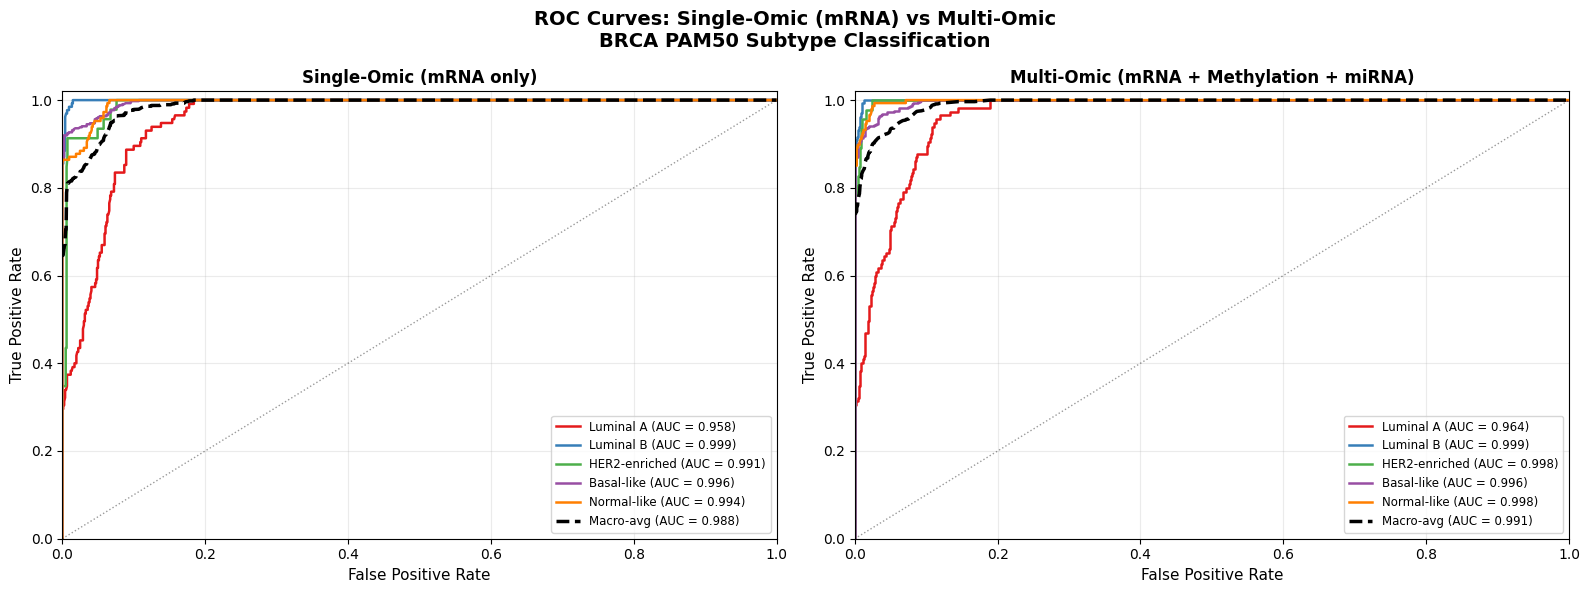

✅ Saved to ./results/ROC_SingleVsMulti.png


In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_bin = label_binarize(all_labels, classes=list(range(CLASS_NUM)))
colors = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ROC Curves: Single-Omic (mRNA) vs Multi-Omic\nBRCA PAM50 Subtype Classification',
             fontsize=14, fontweight='bold')

for ax, probs, title in zip(
    axes,
    [so_probs_all, mo_probs_all],
    ['Single-Omic (mRNA only)', 'Multi-Omic (mRNA + Methylation + miRNA)']
):
    # Per-class ROC
    for i, (name, color) in enumerate(zip(subtype_names, colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=1.8,
                label=f'{name} (AUC = {roc_auc:.3f})')

    # Macro-average ROC
    all_fpr = np.unique(np.concatenate(
        [roc_curve(y_bin[:, i], probs[:, i])[0] for i in range(CLASS_NUM)]
    ))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(CLASS_NUM):
        fpr_i, tpr_i, _ = roc_curve(y_bin[:, i], probs[:, i])
        mean_tpr += np.interp(all_fpr, fpr_i, tpr_i)
    mean_tpr /= CLASS_NUM
    macro_auc = auc(all_fpr, mean_tpr)
    ax.plot(all_fpr, mean_tpr, color='black', lw=2.5, linestyle='--',
            label=f'Macro-avg (AUC = {macro_auc:.3f})')

    ax.plot([0,1],[0,1], 'k:', lw=1, alpha=0.4)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8.5)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('./results/ROC_SingleVsMulti.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to ./results/ROC_SingleVsMulti.png")

# CELL 8: Confusion Matrices — Single-Omic vs Multi-Omic

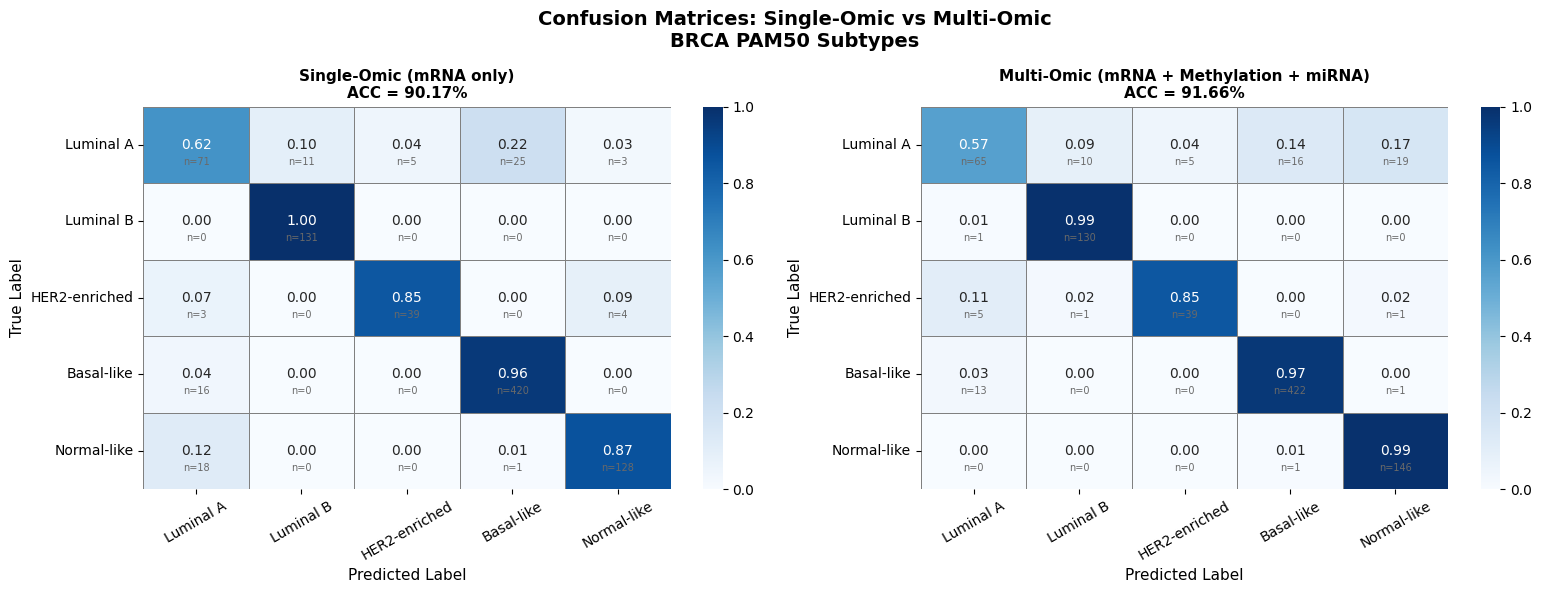

✅ Saved to ./results/ConfusionMatrix_SingleVsMulti.png

🎉 Full pipeline complete. Results saved to ./results/


In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
from scipy.optimize import linear_sum_assignment

def hungarian_remap(y_true, y_pred, n_classes):
    """Remap predicted cluster IDs to best-matching true labels."""
    cost = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cost[t, p] += 1
    row, col = linear_sum_assignment(-cost)
    mapping = {c: r for r, c in zip(row, col)}
    return np.array([mapping.get(p, p) for p in y_pred])

so_preds_mapped = hungarian_remap(all_labels, so_preds, CLASS_NUM)
mo_preds_mapped = hungarian_remap(all_labels, mo_preds, CLASS_NUM)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrices: Single-Omic vs Multi-Omic\nBRCA PAM50 Subtypes',
             fontsize=14, fontweight='bold')

for ax, preds, title, acc in zip(
    axes,
    [so_preds_mapped, mo_preds_mapped],
    ['Single-Omic (mRNA only)', 'Multi-Omic (mRNA + Methylation + miRNA)'],
    [so_acc, mo_acc]
):
    cm = confusion_matrix(all_labels, preds)

    # Normalize row-wise for recall perspective
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', ax=ax,
        cmap='Blues', linewidths=0.5, linecolor='gray',
        xticklabels=subtype_names, yticklabels=subtype_names,
        vmin=0, vmax=1,
        annot_kws={"size": 10}
    )
    # Overlay raw counts in smaller text
    for i in range(CLASS_NUM):
        for j in range(CLASS_NUM):
            ax.text(j + 0.5, i + 0.72, f'n={cm[i,j]}',
                    ha='center', va='center', fontsize=7, color='dimgray')

    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_title(f'{title}\nACC = {acc*100:.2f}%', fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('./results/ConfusionMatrix_SingleVsMulti.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to ./results/ConfusionMatrix_SingleVsMulti.png")
print("\n🎉 Full pipeline complete. Results saved to ./results/")